In [2]:
import numpy as np
import tensorflow as tf
from keras.models import load_model
from keras.applications.resnet import preprocess_input
from keras.layers import Resizing, Conv2D
import os

# Cargar modelo
model = load_model('models\\Mammalia\\model_M2.h5', compile=False)  # compile=False si no necesitas recompilar

# Cargar clases
classes = np.load('models\\Mammalia\\classes_m2.npy')
print("Clases disponibles:", classes)


Clases disponibles: ['Alouatta_seniculus' 'Bradypus_variegatus' 'Cerdocyon_thous'
 'Lontra_longicaudis' 'Panthera_onca' 'Pecari_tajacu' 'Procyon_lotor'
 'Puma_concolor' 'Sciurus_granatensis']


In [29]:
def predict_species(spec):
    """
    Realiza la predicción del nombre de la especie a partir de un espectrograma (1025, 313).
    """
    if spec.shape != (1025, 313):
        raise ValueError("El espectrograma debe tener forma (1025, 313)")

    # # Normalizar
    spec = spec.astype('float32')
    spec /= np.max(spec)

    # Añadir canal y batch dimension
    spec = np.expand_dims(spec[..., np.newaxis], axis=0)  # (1, 1025, 313, 1)   


    pred = model.predict(spec)  # type: ignore
    pred_class_idx = np.argmax(pred)
    pred_class = classes[pred_class_idx]
    prob = pred[0][pred_class_idx]

    return pred_class, prob


In [30]:
# Ruta del nuevo archivo a predecir
new_file = 'Mammalia\\NPZ\\Puma_concolor_iNat878627_chunk3.npz'

# Cargar el espectrograma del archivo
data = np.load(new_file)
spec = data['spec']

# Hacer la predicción
predicted_species, confidence = predict_species(spec)
print(f"Especie predicha: {predicted_species} (confianza: {confidence:.2f})")


1/1 [==============================] - 0s 143ms/step
Especie predicha: Puma_concolor (confianza: 0.94)


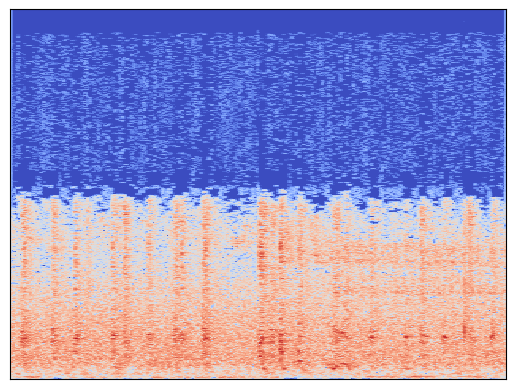

In [26]:
import librosa

librosa.display.specshow(data=spec, sr=32000)